In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv(r"C:\Users\sello\Downloads\Dataset to work on\bank-direct-marketing-campaigns.csv")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [42]:
# Missing values

df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [41]:
# Duplicates & Shape

df = df.drop_duplicates()

df.shape

(39404, 20)

In [40]:
# Data type
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

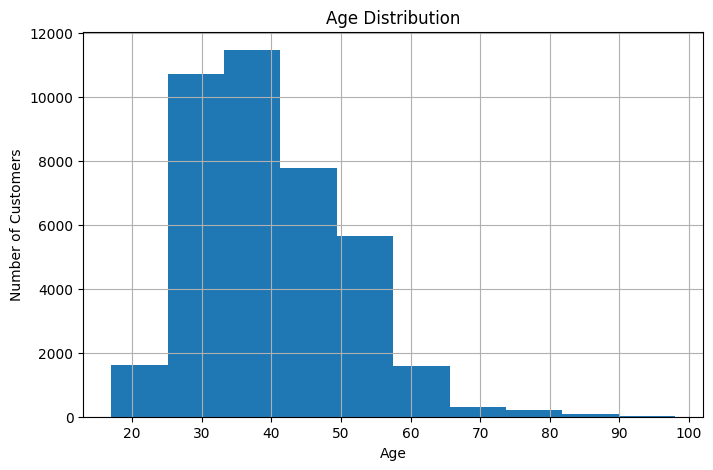

In [39]:
# Age distribution

df["age"].hist(figsize=(8,5))

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [38]:
# Job type

df["job"].value_counts()

job
admin.           9873
blue-collar      8835
technician       6404
services         3801
management       2820
retired          1683
entrepreneur     1405
self-employed    1386
housemaid        1028
unemployed        992
student           852
unknown           325
Name: count, dtype: int64

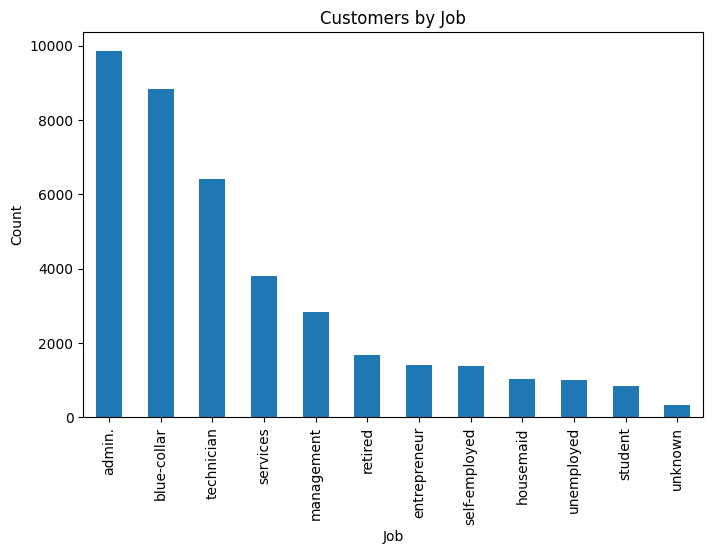

In [15]:
df["job"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Customers by Job")

plt.xlabel("Job")

plt.ylabel("Count")

plt.show()

In [37]:
# Customers married,single, divorced, unknown

df["marital"].value_counts()

marital
married     23869
single      10997
divorced     4459
unknown        79
Name: count, dtype: int64

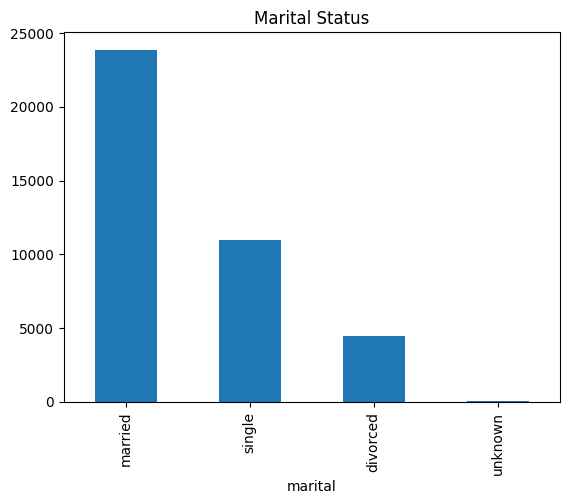

In [19]:
df["marital"].value_counts().plot(kind="bar")

plt.title("Marital Status")

plt.show()

In [35]:
# Education level that appears most frequently

df["education"].value_counts()

education
university.degree      11561
high.school             9121
basic.9y                5785
professional.course     5018
basic.4y                3993
basic.6y                2222
unknown                 1686
illiterate                18
Name: count, dtype: int64

In [36]:
# Customers with housing loans

df["housing"].value_counts()

housing
yes        20561
no         17863
unknown      980
Name: count, dtype: int64

In [34]:
# Customers with personal loans

df["loan"].value_counts()

loan
no         32248
yes         6176
unknown      980
Name: count, dtype: int64

In [29]:
# Average customer age

df["age"].mean()

np.float64(40.116104963963046)

In [30]:
# Youngest Customer

df["age"].min()

np.int64(17)

In [31]:
# Oldest Customer

df["age"].max()

np.int64(98)

In [28]:
# Month with most marketing contacts

df["month"].value_counts()

month
may    13315
jul     6698
aug     5719
jun     5245
nov     3910
apr     2535
oct      707
sep      564
mar      530
dec      181
Name: count, dtype: int64

In [45]:
# Contacts made during each campaign

df["campaign"].value_counts().sort_index()

campaign
1     16368
2     10223
3      5230
4      2625
5      1586
6       974
7       623
8       400
9       283
10      224
11      177
12      125
13       91
14       69
15       51
16       51
17       58
18       33
19       26
20       30
21       24
22       17
23       16
24       15
25        8
26        8
27       11
28        8
29       10
30        7
31        7
32        4
33        4
34        3
35        5
37        1
39        1
40        2
41        1
42        2
43        2
56        1
Name: count, dtype: int64

In [48]:
# Average age by marital status

df.groupby("marital")["age"].mean()

marital
divorced    44.912312
married     42.395995
single      33.220697
unknown     40.417722
Name: age, dtype: float64

In [51]:
# Subscription rate by education level

pd.crosstab(df["education"], df["y"])

y,no,yes
education,,
basic.4y,3568,425
basic.6y,2034,188
basic.9y,5319,466
high.school,8098,1023
illiterate,14,4
professional.course,4426,592
university.degree,9910,1651
unknown,1437,249


In [53]:
# Subscrption rate by job type

pd.crosstab(df["job"], df["y"])

y,no,yes
job,,
admin.,8538,1335
blue-collar,8202,633
entrepreneur,1284,121
housemaid,922,106
management,2494,326
retired,1252,431
self-employed,1237,149
services,3479,322
student,581,271


In [54]:
# Relationship between housing loan and subscription

pd.crosstab(df["housing"], df["y"])

y,no,yes
housing,,
no,15851,2012
unknown,873,107
yes,18082,2479


In [56]:
# Numeric variables that are correlated

numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,0.000990,-0.033556,0.022051,0.002199,0.000954,0.128851,0.012970,-0.014800
campaign,0.000990,1.000000,0.056527,-0.084663,0.158225,0.128093,-0.014252,0.142438,0.152535
pdays,-0.033556,0.056527,1.000000,-0.588981,0.273821,0.080392,-0.092785,0.300021,0.375664
previous,0.022051,-0.084663,-0.588981,1.000000,-0.422050,-0.203900,-0.049526,-0.456498,-0.503055
emp.var.rate,0.002199,0.158225,0.273821,-0.422050,1.000000,0.776480,0.187151,0.971919,0.905359
cons.price.idx,0.000954,0.128093,0.080392,-0.203900,0.776480,1.000000,0.054682,0.687596,0.519677
cons.conf.idx,0.128851,-0.014252,-0.092785,-0.049526,0.187151,0.054682,1.000000,0.270182,0.092497
euribor3m,0.012970,0.142438,0.300021,-0.456498,0.971919,0.687596,0.270182,1.000000,0.944573
nr.employed,-0.014800,0.152535,0.375664,-0.503055,0.905359,0.519677,0.092497,0.944573,1.000000


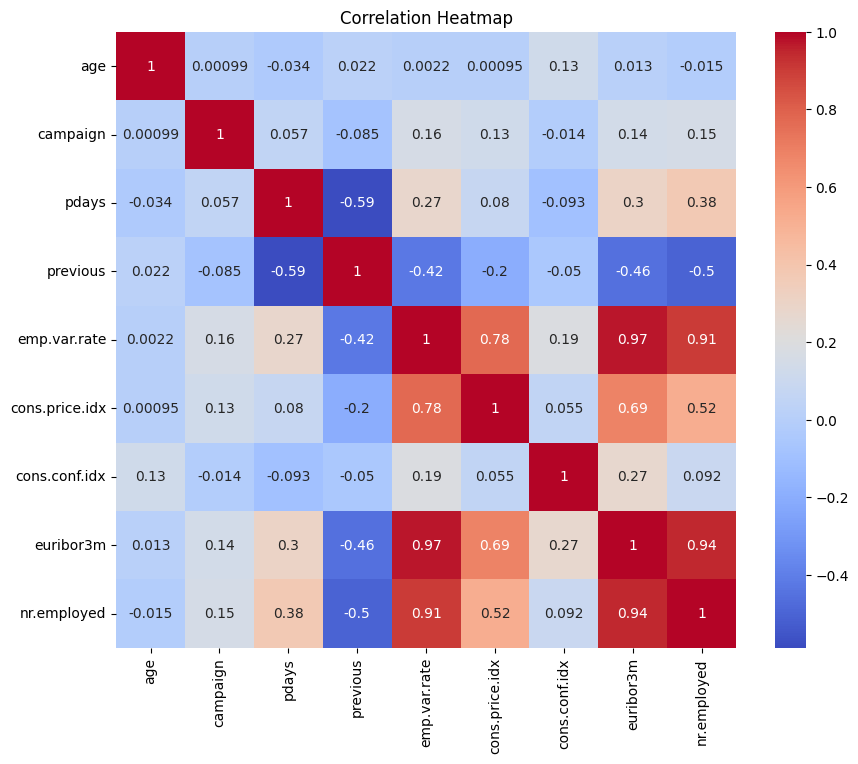

In [57]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()